<a href="https://colab.research.google.com/github/SofiaKakou/Customer_Churn_Prediction/blob/main/notebooks/012_bank_shap_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Introduction

This notebook focuses on interpreting the machine learning model using SHAP (SHapley Additive exPlanations)

Purpose:
- Understand how features influence model predictions
- identify key drivers of customer churn
- explain both global and individual predictions

This is important for translatng machine learning results into actionable business insights.


# 2.Imports


In [1]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

# 3.Load Dataset & Model

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load the prepared datasets
base_path = "/content/drive/MyDrive/Thesis/Prepared Data/"

x_train = pd.read_csv(base_path + "bank_x_train.csv")
x_test = pd.read_csv(base_path + "bank_x_test.csv")

y_train = pd.read_csv(base_path + "bank_y_train.csv").values.ravel()
y_test = pd.read_csv(base_path + "bank_y_test.csv").values.ravel()

In [4]:
# Load / Retrain RF Model

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

# 4.SHAP Setup

In [9]:
# Creating a smaller sample for SHAP Calculation
x_sample = x_test.sample(200, random_state=42)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP Values
shap_values = explainer.shap_values(x_sample)

# 5.Global SHAP Analysis

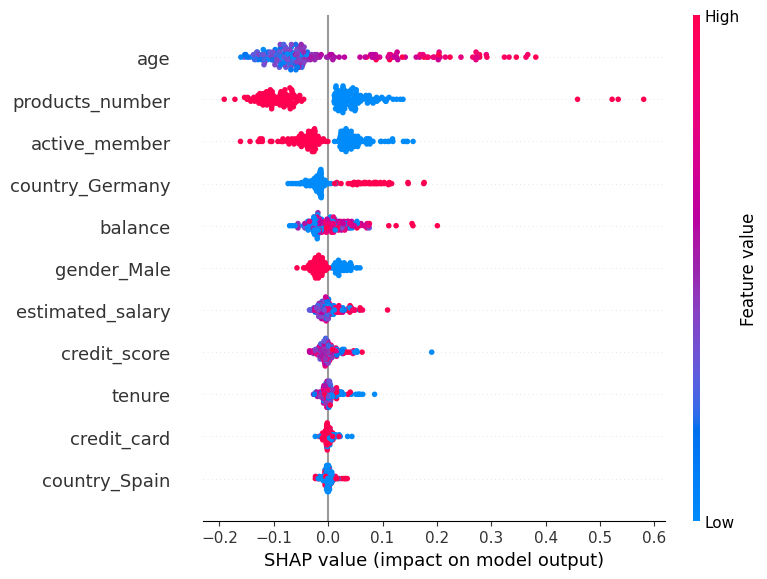

In [10]:
shap.summary_plot(shap_values[:, :, 1], x_sample)

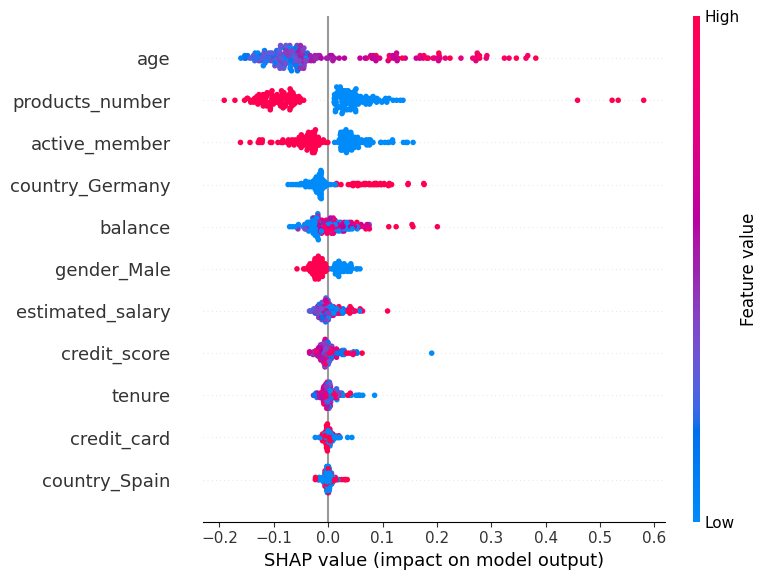

In [13]:
# saving the plot for SHAP
shap.summary_plot(shap_values[:, :, 1], x_sample, show=False)
plt.tight_layout()
plt.savefig(base_path + 'bank_shap_summary.png', bbox_inches="tight", dpi=300)
plt.show()

## Observations

The SHAP summary plot shows the overall impact of each feature on model predictions.
Features at the top have the strongest influence on churn prediction.
Color indicates feature value (red = high, blue = low)
Features with wider spread have greater impact

This provides global understanding of which variables drive churn.

# 6.Bar Plot

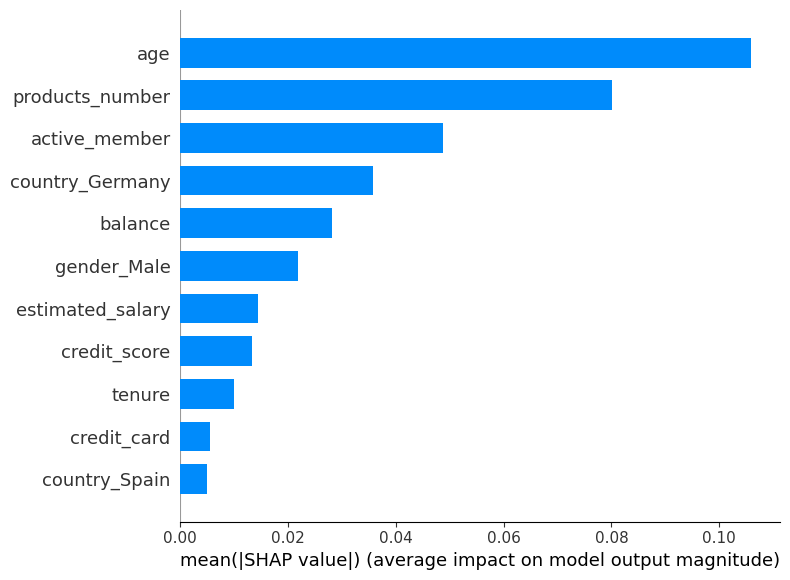

In [14]:
shap.summary_plot(shap_values[:, :, 1], x_sample, plot_type="bar")

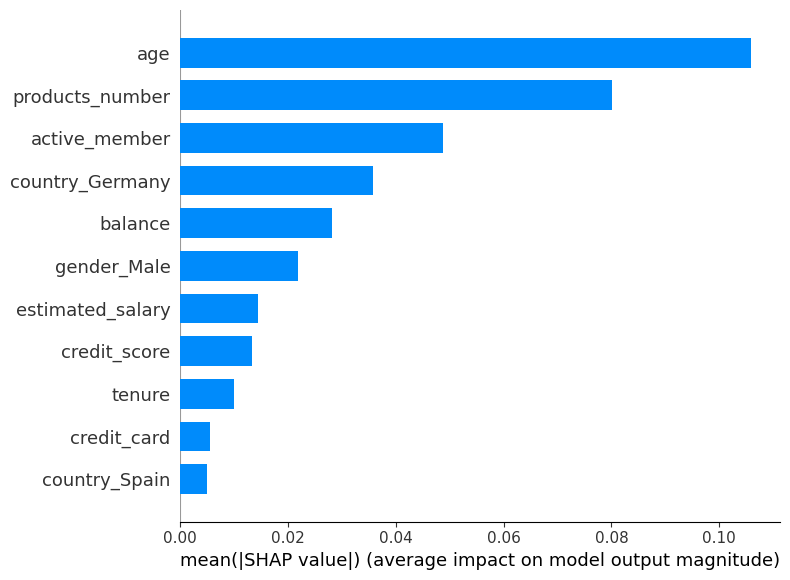

In [15]:
shap.summary_plot(shap_values[:, :, 1], x_sample, plot_type="bar", show=False)

plt.tight_layout()
plt.savefig(base_path + 'bank_shap_bar.png', bbox_inches="tight", dpi=300)
plt.show()

  ## Comments

  The bar plot provides a simplified ranking of feature importance based on SHAP values.
  This helps identify the most influential predictors in a clear and interpretable way.

# 7.Local SHAP Analysis

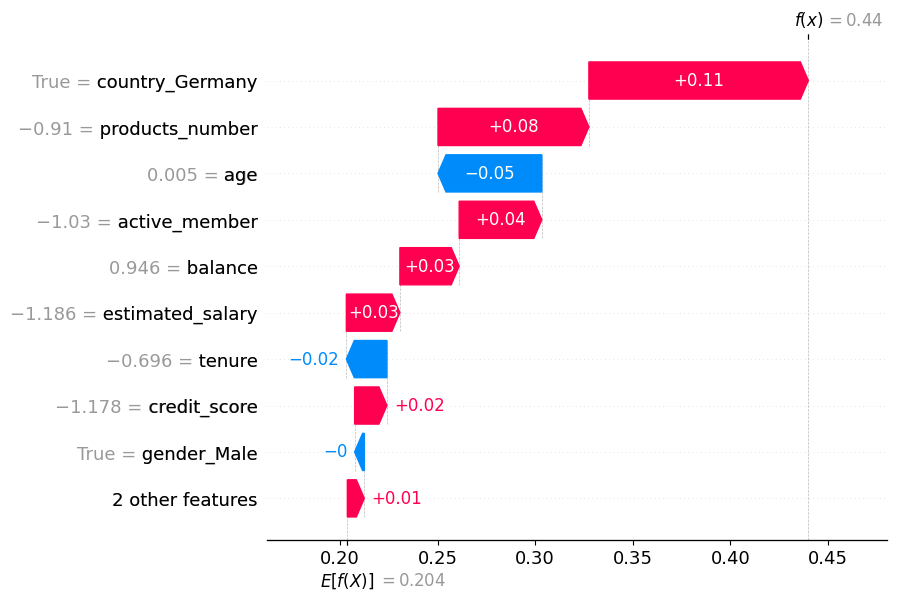

In [17]:
# One example
shap.initjs()
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:, :, 1][sample_index],
        base_values=explainer.expected_value[1],
        data=x_sample.iloc[sample_index],
        feature_names=x_sample.columns,
    )
)

## Comments

The waterfall plot explains the prediction for an individual customer by showing how each feature contributed to the final churn probability. In this instance, country_Germany and products_number were the strongest factors increasing the predicted likelihood of churn, while age and tenure contributed toward reducing the predicition. Unlike the global SHAP summary plot, the waterfall plot reflects customer specific feature interactions, meaning a feature may influence individual predictions differently from its overall trend across a dataset.

## Key Insights

Based on SHAP Insights

- Age, balance and country were among the most influential factors associated with customer churn
- Active members were less likely to churn, indicating that customer engagement plays an important role in retention
- SHAP analysis impoved model interpretability by explaining how individual features contributed to churn predictions.

# 8.Business Interpretation

The analysis identified key factors influencing customer chrn, particularly age, balance, customer activity and country. These results suggest that less engaged customers are likely to leave the bank, highlighting the importance of customer retention and engagement strategies.

The predictive models can help banks identify customers at risk of churning and support proactive actions such as personalized offers and improved customer service. Additionally the use of SHAP explanations improves model transparency by showing how individual features influence churn predictions.

# 9.Dashboard Preparation

In [18]:
# save sample set for dashboard
x_test.head(100).to_csv(base_path + "bank_dashboard_sample.csv", index=False)

print("Dashboard Files prepared successfully.")

Dashboard Files prepared successfully.
